# 01 - Baseline par seuillage

Objectif : construire une premiere methode simple, sans apprentissage, pour comparer ensuite avec le Machine Learning et le Deep Learning.

In [2]:
import sys
from pathlib import Path
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from water_detection_methods.data import find_water_v2_pairs, load_pair
from water_detection_methods.metrics import dice_coefficient, intersection_over_union
from water_detection_methods.visualization import show_image_mask_overlay 

In [3]:
def simple_blue_water_threshold(image):
    red = image[:, :, 0]
    green = image[:, :, 1]
    blue = image[:, :, 2]
    return ((blue > red * 1.05) & (blue > green * 0.85) & (blue > 0.18)).astype(np.uint8)

IoU: 0.6005891337560537
Dice: 0.7504600913369908


(<Figure size 1400x400 with 3 Axes>,
 array([<Axes: title={'center': 'Image'}>,
        <Axes: title={'center': 'Masque eau'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

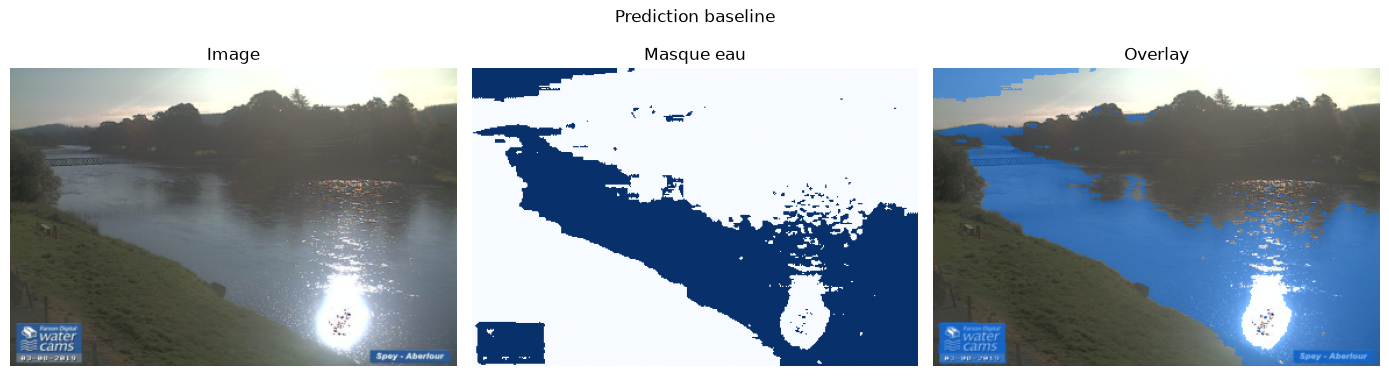

In [ ]:
pairs = find_water_v2_pairs(ROOT / "water_v2")
image, true_mask = load_pair(*pairs[0], size=(384, 256))
pred_mask = simple_blue_water_threshold(image)

print("IoU:", intersection_over_union(true_mask, pred_mask))
print("Dice:", dice_coefficient(true_mask, pred_mask))
show_image_mask_overlay(image, pred_mask, title="Prediction baseline")